In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Credit_Card_Dataset.csv')


# Default Correlation Graphs

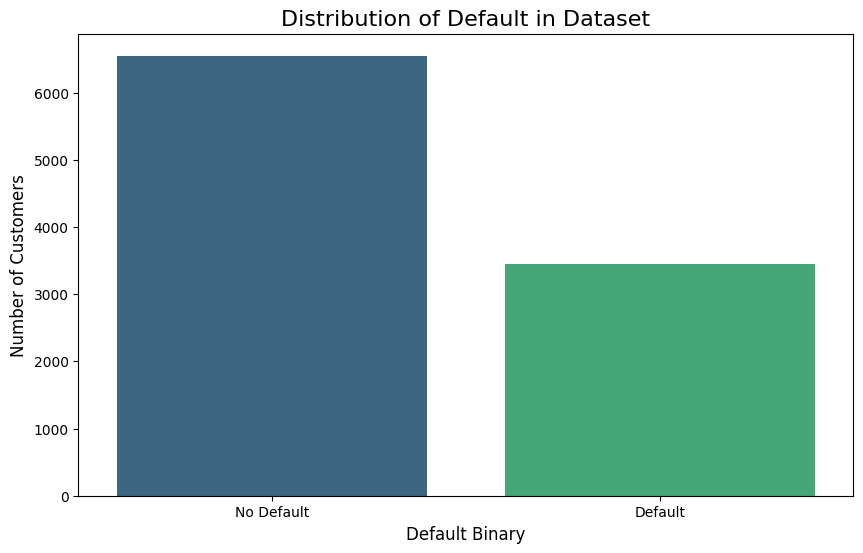

The initial distribution of the dataset in terms of our target variable of defaults is that there is a 6,500 'No Default' and 3,500 'Default'


In [4]:
# 1. Update the map (assuming 0=No, 1=Yes)
default_map = {0: "No Default", 1: "Default"}
df["default_label"] = df["Defaulted"].map(default_map)

# 2. Updated Plotting Code
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df, 
    x="default_label", 
    hue="default_label", # Fixed the Futurewarding by assigning hue
    palette="viridis", 
    order=["No Default", "Default"],
    legend=False 
)

plt.title("Distribution of Default in Dataset", fontsize=16)
plt.xlabel("Default Binary", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.show()
print("The initial distribution of the dataset in terms of our target variable of defaults is that there is a 6,500 'No Default' and 3,500 'Default'")

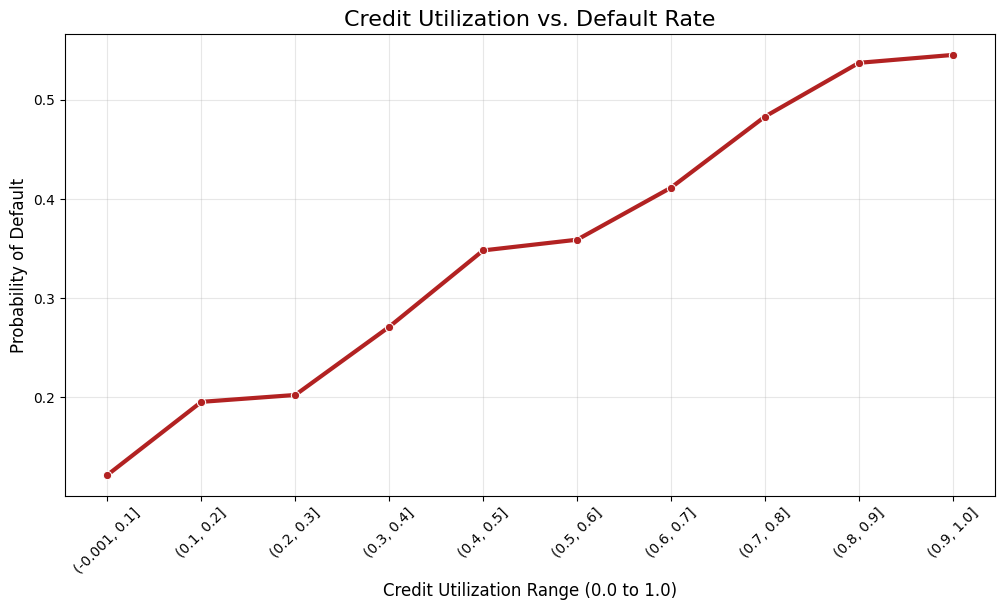

Default probability increaases as utilisation rises which indicates that customers that use a higher percentage of their credit limit are more likely to default

Customers approaching a high utilisation represent a higher credit risk segment and therefore the bank could implement early monitoring systems to help protect themselves


In [5]:
# 1. Create Utilization Bins (Grouping makes the correlation much clearer)
df['util_bins'] = pd.cut(df['Credit_Utilization_Ratio'], bins=10)

# 2. Calculate the mean default rate per bin
util_trend = df.groupby('util_bins', observed=True)['Defaulted'].mean().reset_index()

# 3. Convert the bins to strings for the x-axis
util_trend['util_bins'] = util_trend['util_bins'].astype(str)

# 4. Plot the trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=util_trend, x='util_bins', y='Defaulted', marker='o', color='firebrick', linewidth=3)

plt.title('Credit Utilization vs. Default Rate', fontsize=16)
plt.xlabel('Credit Utilization Range (0.0 to 1.0)', fontsize=12)
plt.ylabel('Probability of Default', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()
print("Default probability increaases as utilisation rises which indicates that customers that use a higher percentage of their credit limit are more likely to default")
print("\nCustomers approaching a high utilisation represent a higher credit risk segment and therefore the bank could implement early monitoring systems to help protect themselves")

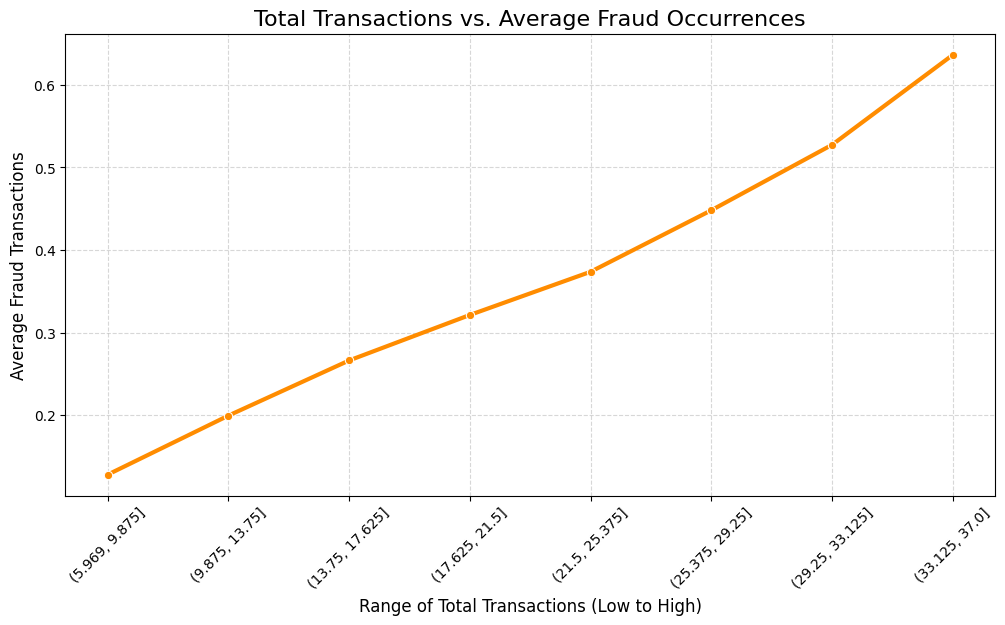

Fraud occureneces tend to increase as the number of transactions grows, suggesting that higher activity accounts present more fraud expsure

This is an important variable to keep an eye as the pattern can be incorporated into our fraud prediction models


In [6]:
# 1. Group total transactions into 8 clean bins/ranges
df['Total_Transactions_Bins'] = pd.cut(df['Total_Transactions'], bins=8)

# 2. Calculate average fraud occurrences for each bin
fraud_trend = df.groupby('Total_Transactions_Bins', observed=True)['Fraud_Transactions'].mean().reset_index()

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=fraud_trend, 
    x=fraud_trend['Total_Transactions_Bins'].astype(str), 
    y='Fraud_Transactions', 
    marker='o', 
    color='darkorange', 
    linewidth=3
)

plt.title('Total Transactions vs. Average Fraud Occurrences', fontsize=16)
plt.xlabel('Range of Total Transactions (Low to High)', fontsize=12)
plt.ylabel('Average Fraud Transactions', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
print("Fraud occureneces tend to increase as the number of transactions grows, suggesting that higher activity accounts present more fraud expsure")
print("\nThis is an important variable to keep an eye as the pattern can be incorporated into our fraud prediction models")

# Spend/Credit Correlation Graphs

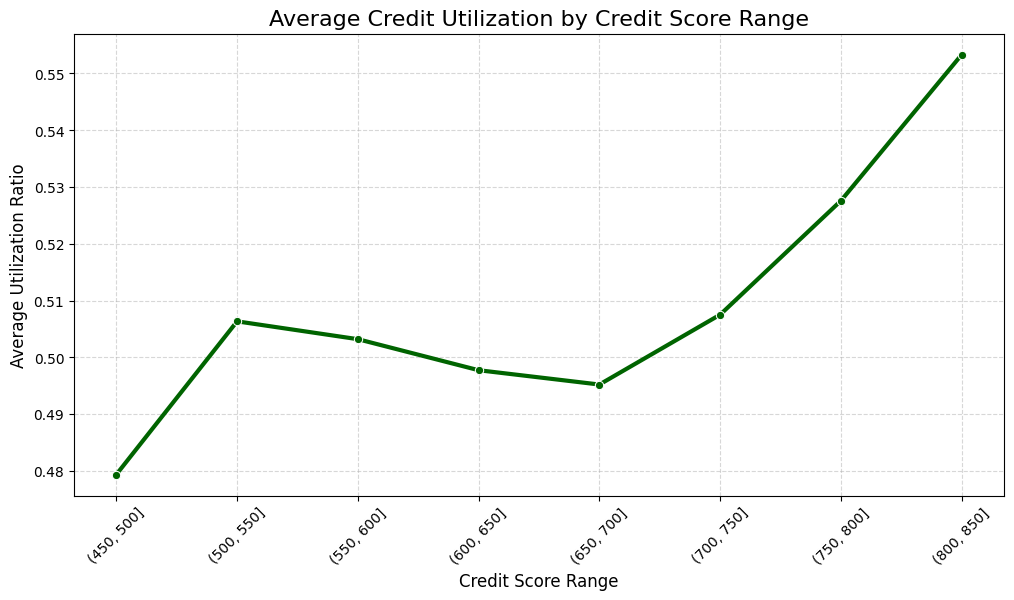

Customers with lower credit scores generally have higher credit utilisation which aligns with the potential financial stress that they are under


In [7]:
# 1. Create Credit Score Bins (e.g., in steps of 50)
score_bins = [450, 500, 550, 600, 650, 700, 750, 800, 850]
df['score_range'] = pd.cut(df['Credit_Score'], bins=score_bins)

# 2. Calculate the mean utilization for each score range
score_trend = df.groupby('score_range', observed=True)['Credit_Utilization_Ratio'].mean().reset_index()

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=score_trend, 
    x=score_trend['score_range'].astype(str), 
    y='Credit_Utilization_Ratio', 
    marker='o', 
    linewidth=3, 
    color='darkgreen'
)

plt.title('Average Credit Utilization by Credit Score Range', fontsize=16)
plt.xlabel('Credit Score Range', fontsize=12)
plt.ylabel('Average Utilization Ratio', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
print("Customers with lower credit scores generally have higher credit utilisation which aligns with the potential financial stress that they are under")

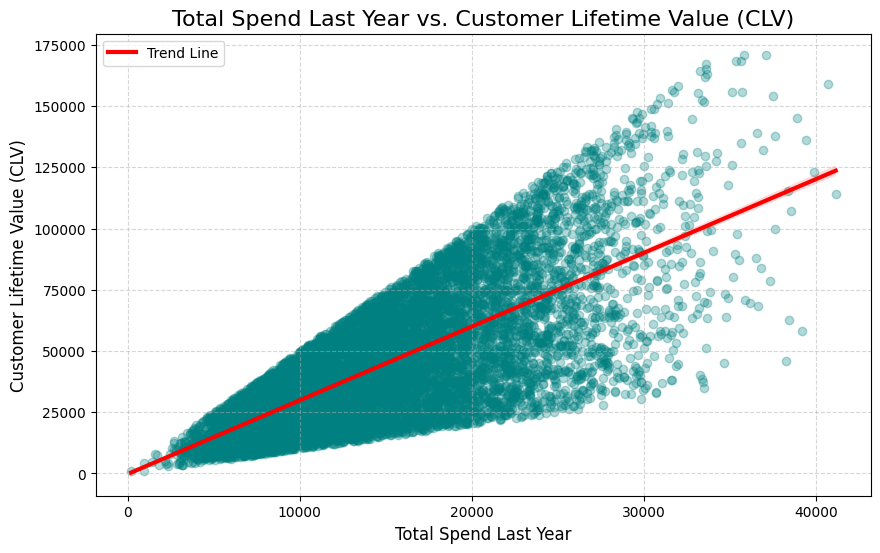

A strong positive relationships suggests that customers who spend more annualy tend to generate a higher lifetime value

High spending customers respresent strategic opportunities for the company to work on for marketing and and rewards


In [8]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df, 
    x='Total_Spend_Last_Year', 
    y='CLV',
    scatter_kws={'alpha': 0.3, 'color': 'teal'},
    line_kws={'color': 'red', 'linewidth': 3, 'label': 'Trend Line'}
)

plt.title('Total Spend Last Year vs. Customer Lifetime Value (CLV)', fontsize=16)
plt.xlabel('Total Spend Last Year', fontsize=12)
plt.ylabel('Customer Lifetime Value (CLV)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
print("A strong positive relationships suggests that customers who spend more annualy tend to generate a higher lifetime value")
print("\nHigh spending customers respresent strategic opportunities for the company to work on for marketing and and rewards")

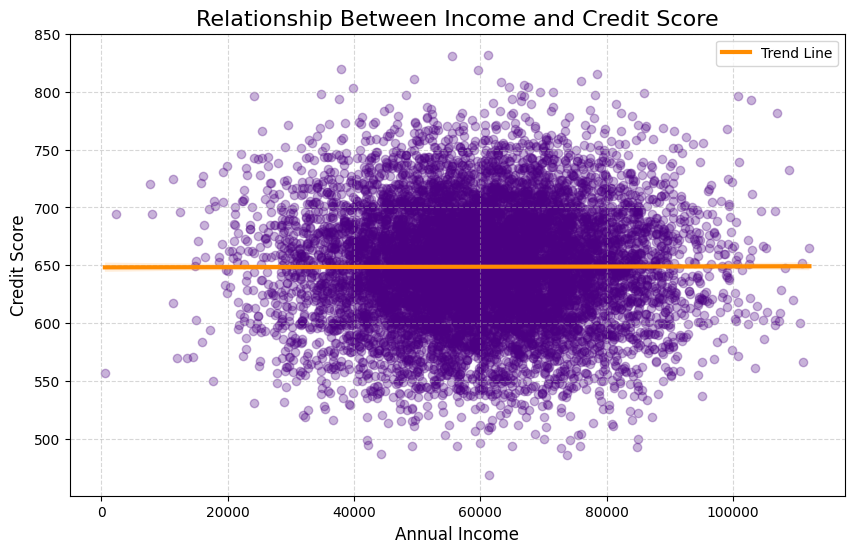

There is a moderate positive relationship betweem income and credit score, however variability in the data shows that it is not the only variable.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('Credit_Card_Dataset.csv')

# 2. Create the plot
plt.figure(figsize=(10, 6))

# A scatter plot with a regression line to show the trend
sns.regplot(
    data=df, 
    x='Annual_Income', 
    y='Credit_Score',
    scatter_kws={'alpha': 0.3, 'color': 'indigo'}, # The 'alpha' makes dots transparent so we can see dense clusters
    line_kws={'color': 'darkorange', 'linewidth': 3, 'label': 'Trend Line'}
)

plt.title('Relationship Between Income and Credit Score', fontsize=16)
plt.xlabel('Annual Income', fontsize=12)
plt.ylabel('Credit Score', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 3. Display the plot
plt.show()
print("There is a moderate positive relationship betweem income and credit score, however variability in the data shows that it is not the only variable.")

# Fraud Correlation Graphs

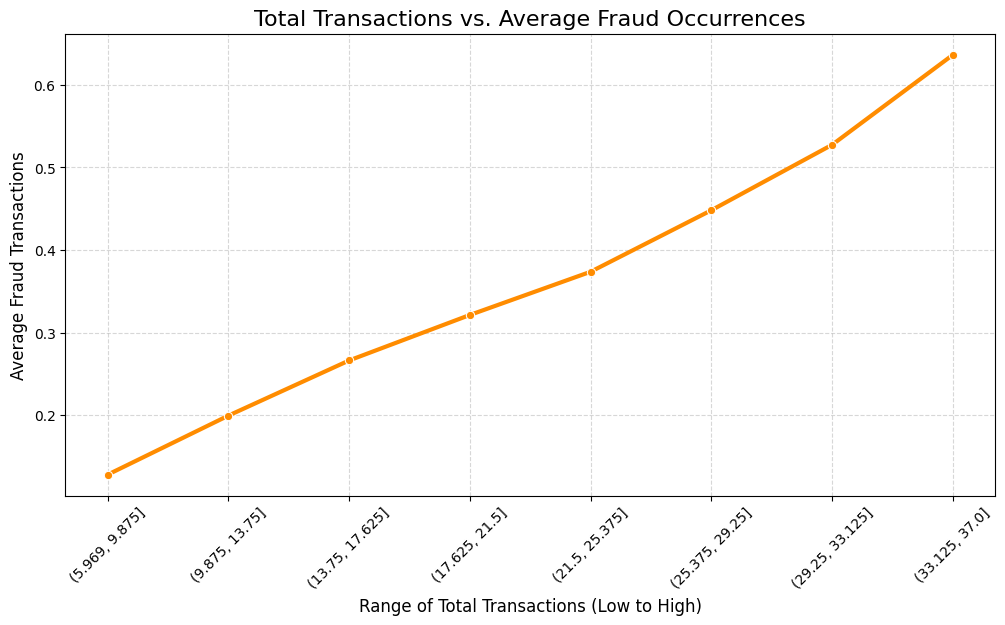

In [10]:
# 1. Group total transactions into 8 clean bins/ranges
df['Total_Transactions_Bins'] = pd.cut(df['Total_Transactions'], bins=8)

# 2. Calculate average fraud occurrences for each bin
fraud_trend = df.groupby('Total_Transactions_Bins', observed=True)['Fraud_Transactions'].mean().reset_index()

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=fraud_trend, 
    x=fraud_trend['Total_Transactions_Bins'].astype(str), 
    y='Fraud_Transactions', 
    marker='o', 
    color='darkorange', 
    linewidth=3
)

plt.title('Total Transactions vs. Average Fraud Occurrences', fontsize=16)
plt.xlabel('Range of Total Transactions (Low to High)', fontsize=12)
plt.ylabel('Average Fraud Transactions', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
print("")

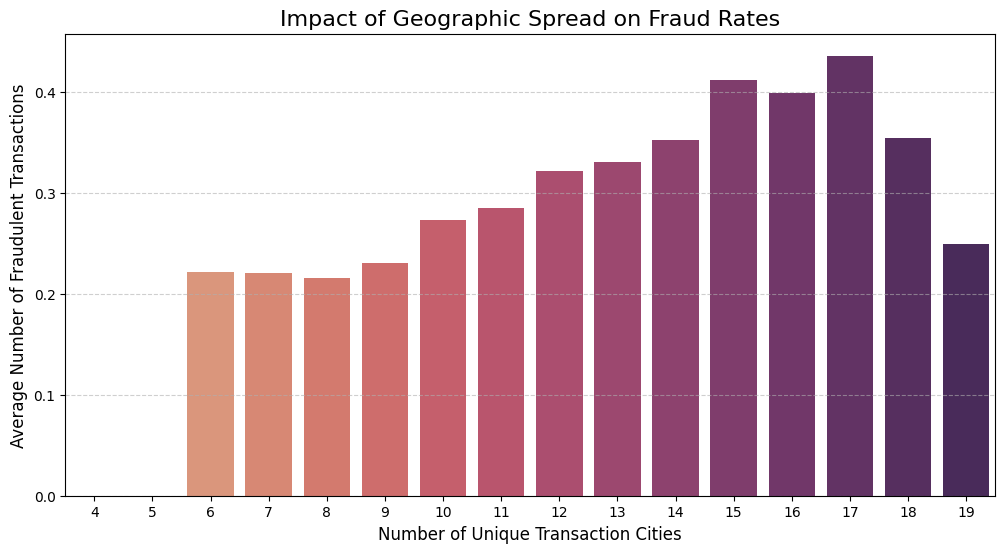

Fraud levels increase as ntransactions occur across a larger number of cities which could indicate suspicious travel or card misuse

The bank can use geographical transaction patterns as part of the fraud detection system


In [11]:
# 1. Group by the number of unique cities and calculate the average fraud rate
city_fraud_trend = df.groupby('Unique_Transaction_Cities')['Fraud_Transactions'].mean().reset_index()

# 2. Plotting
plt.figure(figsize=(12, 6))

# A barplot with a color gradient shows the escalating risk perfectly
sns.barplot(
    data=city_fraud_trend, 
    x='Unique_Transaction_Cities', 
    y='Fraud_Transactions', 
    palette='flare',      # 'flare' or 'Reds' works great for fraud/danger
    hue='Unique_Transaction_Cities',
    legend=False
)

plt.title('Impact of Geographic Spread on Fraud Rates', fontsize=16)
plt.xlabel('Number of Unique Transaction Cities', fontsize=12)
plt.ylabel('Average Number of Fraudulent Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
print("Fraud levels increase as ntransactions occur across a larger number of cities which could indicate suspicious travel or card misuse")
print("\nThe bank can use geographical transaction patterns as part of the fraud detection system")

In [12]:
# 1. Group by the number of unique merchant categories and calculate the average fraud rate
category_fraud_trend = df.groupby('Unique_Merchant_Categories')['Fraud_Transactions'].mean().reset_index()

# 2. Plotting
plt.figure(figsize=(12, 6))

# A barplot with a color gradient shows the escalating risk
ax = sns.barplot(
    data=category_fraud_trend, 
    x='Unique_Merchant_Categories', 
    y='Fraud_Transactions', 
    palette='magma',      # 'magma' gives a great dark-to-light progression
    hue='Unique_Merchant_Categories'
)

# Clean up the legend (if one accidentally appears)
if ax.get_legend():
    ax.get_legend().remove()

plt.title('Impact of Diverse Merchant Spending on Fraud Rates', fontsize=16)
plt.xlabel('Number of Unique Merchant Categories', fontsize=12)
plt.ylabel('Average Number of Fraudulent Transactions', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()
print("Fraud incidents increase with greater diversity in merchant categories suggesting that ununsual spending behaviout can msignal risk")
print("\nFraudsters could be testing the card limits by spending at different locations. Monitoring sudden increases in diversity could imprive the early fraud detection algorithms


SyntaxError: unterminated string literal (detected at line 26) (1565527800.py, line 26)

# K Means Cluster Graphs

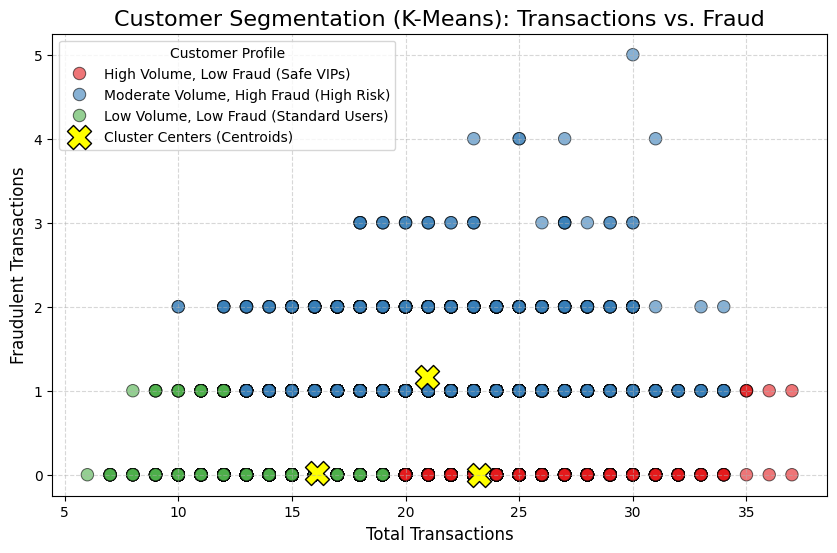

--- Average Values per Customer Segment ---
                                         Total_Transactions  \
Customer_Segment                                              
High Volume, Low Fraud (Safe VIPs)                23.229658   
Low Volume, Low Fraud (Standard Users)            16.089909   
Moderate Volume, High Fraud (High Risk)           20.938088   

                                         Fraud_Transactions  
Customer_Segment                                             
High Volume, Low Fraud (Safe VIPs)                 0.001389  
Low Volume, Low Fraud (Standard Users)             0.016772  
Moderate Volume, High Fraud (High Risk)            1.167994  


In [13]:
# 1. Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 2. Load the dataset
df = pd.read_csv('Credit_Card_Dataset.csv')

# 3. Select the features for clustering
features = ['Total_Transactions', 'Fraud_Transactions']
X = df[features]

# 4. Scale the data
# K-Means calculates physical distance between points. We MUST scale the data 
# so 'Total_Transactions' (which can be 30+) doesn't mathematically overpower 
# 'Fraud_Transactions' (which is usually 0-5).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Build the K-Means Model
# We set n_clusters=3 to create 3 distinct "Customer Segments"
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Map the clusters to meaningful business names
segment_names = {
    0: 'High Volume, Low Fraud (Safe VIPs)', 
    1: 'Moderate Volume, High Fraud (High Risk)', 
    2: 'Low Volume, Low Fraud (Standard Users)'
}
df['Customer_Segment'] = df['Cluster'].map(segment_names)

# 6. VISUALIZATION: The Scatter Plot
plt.figure(figsize=(10, 6))

# Plot the individual customers
sns.scatterplot(
    data=df,
    x='Total_Transactions',
    y='Fraud_Transactions',
    hue='Customer_Segment',
    palette='Set1',
    s=80,      # Size of the dots
    alpha=0.6, # Transparency to see overlapping points
    edgecolor='black'
)

# 7. Add the Cluster Centers (The "Centroids")
# We have to reverse the scaling so the "X" marks show up on the correct normal numbers
centers_unscaled = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers_unscaled[:, 0], 
    centers_unscaled[:, 1], 
    c='yellow', 
    s=300, 
    marker='X', 
    edgecolor='black', 
    label='Cluster Centers (Centroids)'
)

plt.title('Customer Segmentation (K-Means): Transactions vs. Fraud', fontsize=16)
plt.xlabel('Total Transactions', fontsize=12)
plt.ylabel('Fraudulent Transactions', fontsize=12)
plt.legend(title='Customer Profile')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 8. Print the averages for each cluster for your report!
print("--- Average Values per Customer Segment ---")
print(df.groupby('Customer_Segment')[features].mean())

Number of customers in 30k–70k range: 7192


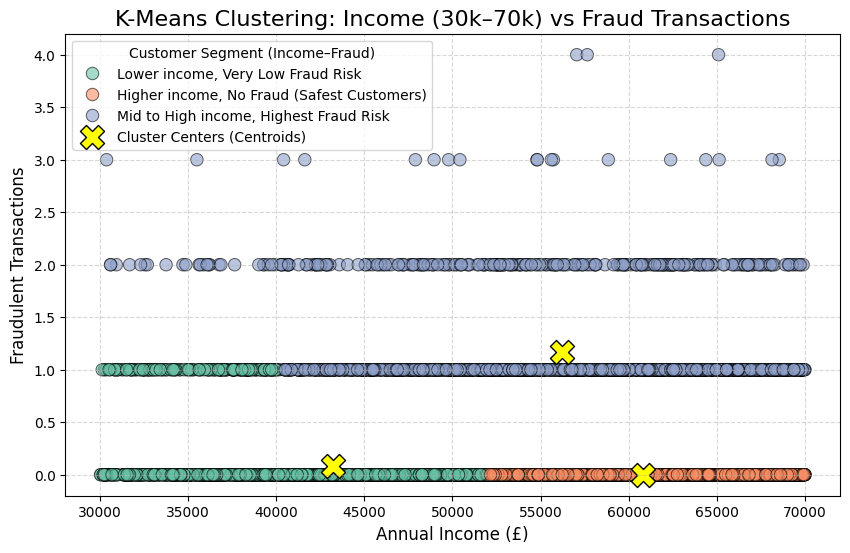

--- Average Values per Income–Fraud Segment (30k–70k income only) ---
                                            Annual_Income  Fraud_Transactions
Income_Fraud_Segment                                                         
Higher income, No Fraud (Safest Customers)   60835.366964            0.000000
Lower income, Very Low Fraud Risk            43280.594647            0.079319
Mid to High income, Highest Fraud Risk       56198.336161            1.172853


In [14]:
# === K-MEANS: Income (30k–70k) vs Fraud_Transactions ===

# 1. Filter to only customers with income between 30k and 70k
income_min, income_max = 30000, 70000

df_income = df[(df['Annual_Income'] >= income_min) & 
               (df['Annual_Income'] <= income_max)].copy()

print(f"Number of customers in {income_min/1000:.0f}k–{income_max/1000:.0f}k range:",
      len(df_income))

# 2. Select features for clustering
income_features = ['Annual_Income', 'Fraud_Transactions']
X_income = df_income[income_features]

# 3. Scale the data (very important for K-Means)
income_scaler = StandardScaler()
X_income_scaled = income_scaler.fit_transform(X_income)

# 4. Build the K-Means model (again, 3 clusters)
kmeans_income = KMeans(n_clusters=3, random_state=42, n_init=10)
df_income['Income_Fraud_Cluster'] = kmeans_income.fit_predict(X_income_scaled)

# (Optional) Give simple names to the clusters
income_segment_names = {
    0: 'Lower income, Very Low Fraud Risk',
    1: 'Higher income, No Fraud (Safest Customers)',
    2: 'Mid to High income, Highest Fraud Risk'
}
df_income['Income_Fraud_Segment'] = df_income['Income_Fraud_Cluster'].map(income_segment_names)

# 5. Get unscaled cluster centers for plotting
income_centers_unscaled = income_scaler.inverse_transform(kmeans_income.cluster_centers_)

# 6. Scatter "blob" plot: Income vs Fraud
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_income,
    x='Annual_Income',
    y='Fraud_Transactions',
    hue='Income_Fraud_Segment',   # or 'Income_Fraud_Cluster' if you prefer numbers
    palette='Set2',
    s=80,
    alpha=0.6,
    edgecolor='black'
)

# Plot the centroids
plt.scatter(
    income_centers_unscaled[:, 0],
    income_centers_unscaled[:, 1],
    c='yellow',
    s=300,
    marker='X',
    edgecolor='black',
    label='Cluster Centers (Centroids)'
)

plt.title('K-Means Clustering: Income (30k–70k) vs Fraud Transactions', fontsize=16)
plt.xlabel('Annual Income (£)', fontsize=12)
plt.ylabel('Fraudulent Transactions', fontsize=12)
plt.legend(title='Customer Segment (Income–Fraud)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 7. Averages per cluster – handy for your explanation / report
print("--- Average Values per Income–Fraud Segment (30k–70k income only) ---")
print(df_income.groupby('Income_Fraud_Segment')[income_features].mean())

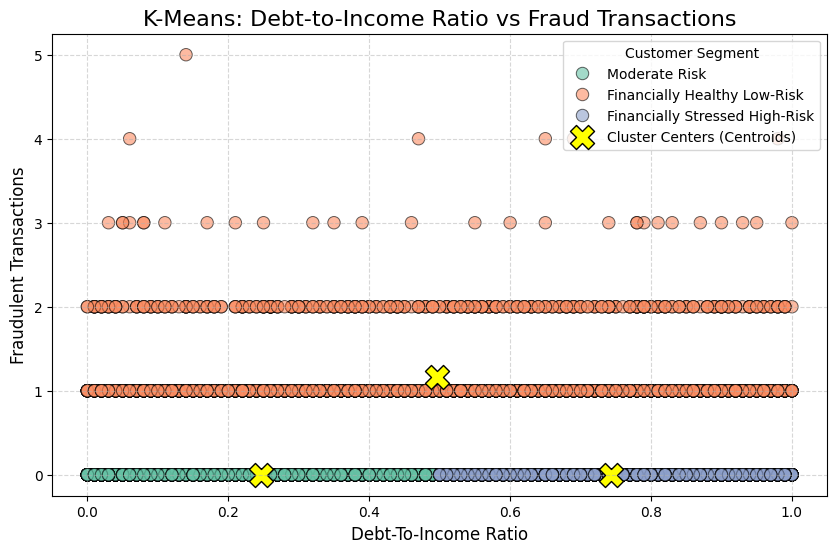

--- Average Values per DTI-Fraud Segment ---
                                Debt_To_Income_Ratio  Fraud_Transactions
DTI_Fraud_Segment                                                       
Financially Healthy Low-Risk                0.496305            1.164074
Financially Stressed High-Risk              0.743688            0.000000
Moderate Risk                               0.246704            0.000000


In [15]:
# === K-MEANS: Debt-to-Income Ratio vs Fraud Transactions ===

# 1. Select features
features_dti = ['Debt_To_Income_Ratio', 'Fraud_Transactions']
X_dti = df[features_dti]

# 2. Scale the data
dti_scaler = StandardScaler()
X_dti_scaled = dti_scaler.fit_transform(X_dti)

# 3. Build the K-Means model
kmeans_dti = KMeans(n_clusters=3, random_state=42, n_init=10)
df['DTI_Fraud_Cluster'] = kmeans_dti.fit_predict(X_dti_scaled)

# 4. Name the clusters
dti_cluster_names = {
    0: 'Financially Stressed High-Risk',
    1: 'Moderate Risk',
    2: 'Financially Healthy Low-Risk'
}
df['DTI_Fraud_Segment'] = df['DTI_Fraud_Cluster'].map(dti_cluster_names)

# 5. Get unscaled centroids
dti_centers_unscaled = dti_scaler.inverse_transform(kmeans_dti.cluster_centers_)

# 6. Plot the results
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Debt_To_Income_Ratio',
    y='Fraud_Transactions',
    hue='DTI_Fraud_Segment',
    palette='Set2',
    s=80,
    alpha=0.6,
    edgecolor='black'
)

# Plot centroid "X" markers
plt.scatter(
    dti_centers_unscaled[:, 0],
    dti_centers_unscaled[:, 1],
    c='yellow',
    s=300,
    marker='X',
    edgecolor='black',
    label='Cluster Centers (Centroids)'
)

plt.title('K-Means: Debt-to-Income Ratio vs Fraud Transactions', fontsize=16)
plt.xlabel('Debt-To-Income Ratio', fontsize=12)
plt.ylabel('Fraudulent Transactions', fontsize=12)
plt.legend(title='Customer Segment')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 7. Print averages for interpretation
print("--- Average Values per DTI-Fraud Segment ---")
print(df.groupby('DTI_Fraud_Segment')[features_dti].mean())